# Notebook 07 — ECAPA-TDNN Domain Adaptation

This is an **optional enhancement** to the meeting-transcription pipeline.
The pretrained ECAPA-TDNN checkpoint used in notebook 02 was trained on **VoxCeleb** —
short, clean, read-aloud clips recorded in controlled studio conditions.
AMI meeting speech is spontaneous, noisy, and multi-speaker.
That domain gap can hurt embedding quality.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Manual mel-spectrogram in numpy — shows what ECAPA actually sees as input | visualization |
| 2 | Extract frozen ECAPA embeddings for 4 AMI training meetings | `(N_train, 192)` matrix |
| 3 | Train a lightweight **speaker adaptation layer** on top of frozen ECAPA | `adaptation_layer.pt` |
| 4 | Apply the trained layer to EN2001a's embeddings → domain-adapted vectors | `(N_eval, 192)` matrix |
| 5 | Compare **before vs. after**: UMAP, silhouette score, intra/inter cosine | comparison table + plots |
| 6 | Save adapted embeddings for notebook 08 (clustering re-run) | JSON on disk |

### Train / eval split

| Role | Meetings | Speakers |
|------|----------|----------|
| **Train** | EN2001b, EN2001d, EN2001e, EN2003a | FEO065 FEO066 MEE067 MEE068 MEO069 MEE074 MEE075 MEE076 |
| **Eval** | EN2001a | FEO065 FEO066 MEE067 MEE068 MEO069 |

EN2001a is **never used during training** — it is held out for evaluation.
The "before" embedding values come directly from notebook 02's saved JSON.

---
## Design Decisions

**Why a domain adaptation layer instead of full ECAPA fine-tuning?**
Full ECAPA-TDNN fine-tuning (~21 M parameters) on CPU would take hours and risks
overfitting to 4 meetings. Instead, we:
1. Use frozen ECAPA as a fixed feature extractor (its VoxCeleb representations are already strong)
2. Train a **tiny MLP** (192 → 256 → 192) to remap those embeddings into an AMI-discriminative space

This is identical in spirit to "last-layer fine-tuning" in transfer learning and is a
well-established technique in speaker recognition literature (e.g., PLDA backend training).
The full pipeline for each segment becomes:

```
audio  →  ECAPA-TDNN (frozen, VoxCeleb)  →  192-dim  →  Adaptation Layer (trained, AMI)  →  192-dim adapted
```

**Training objective:** cross-entropy speaker classification.  
We want the adaptation layer to push same-speaker embeddings closer and different-speaker
embeddings further apart — which is exactly what classification supervision enforces.

**Mel-spectrogram section (Step 1):** This is a pedagogical section, not part of the training
pipeline. SpeechBrain handles feature extraction internally. We implement it in NumPy to show
what the model is actually receiving as input.

---
## Step 0 — Setup

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import Counter

try:
    from speechbrain.inference.classifiers import EncoderClassifier
except ImportError:
    from speechbrain.pretrained import EncoderClassifier

from umap import UMAP
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Meetings ──────────────────────────────────────────────────────────────────
TRAIN_MEETINGS = ["EN2001b", "EN2001d", "EN2001e", "EN2003a"]
EVAL_MEETING   = "EN2001a"   # held out — never seen during training

# ── Paths ─────────────────────────────────────────────────────────────────────
MEETINGS_DIR   = Path("output/meetings")
CHECKPOINT_DIR = Path("checkpoints")
EMBED_DIR      = Path("output/embeddings")
FT_OUT         = Path("output/finetuning")
FT_OUT.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
MIN_UTT_S  = 0.5    # discard utterances shorter than this (unstable embeddings)
MAX_UTT_S  = 10.0   # discard very long utterances
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 1e-3
HIDDEN_DIM = 256

print(f"Device         : {DEVICE.upper()}")
print(f"Train meetings : {TRAIN_MEETINGS}")
print(f"Eval meeting   : {EVAL_MEETING}")

/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device         : CPU
Train meetings : ['EN2001b', 'EN2001d', 'EN2001e', 'EN2003a']
Eval meeting   : EN2001a


---
## Step 1 — Mel-Spectrogram from Scratch (NumPy)

When you call `ecapa.encode_batch(audio)`, SpeechBrain internally computes
**filterbank energies** (log mel-spectrogram) before feeding the signal to the TDNN layers.
Here we implement that feature extraction pipeline entirely in NumPy to make each step explicit.

The pipeline:
```
raw audio (T samples)
    ↓  frame into overlapping windows + Hann window
frames (T_frames × n_fft)
    ↓  real FFT → one-sided power spectrum
power spectrum (T_frames × n_fft/2+1)
    ↓  triangular mel filterbank  (n_mels × n_fft/2+1)
mel energies (n_mels × T_frames)
    ↓  log compression  (stabilises training gradients)
log mel-spectrogram (n_mels × T_frames)
```

**Why mel scale?** Human hearing is approximately logarithmic in frequency.
The mel scale compresses high-frequency resolution (where phoneme differences
matter less for speaker identity) and expands low-frequency resolution — matching
where speaker-specific traits (vocal tract resonances, F0) live.

In [2]:
# ─── Hz ↔ Mel conversions ────────────────────────────────────────────────────

def hz_to_mel(hz):
    """O'Shaughnessy (1987) Hz → Mel.  Vectorised: accepts scalar or array."""
    return 2595.0 * np.log10(1.0 + np.asarray(hz, dtype=float) / 700.0)


def mel_to_hz(mel):
    """Inverse mel conversion."""
    return 700.0 * (10.0 ** (np.asarray(mel, dtype=float) / 2595.0) - 1.0)


def build_mel_filterbank(sr: int, n_fft: int, n_mels: int,
                          f_min: float = 80.0, f_max: float = None) -> np.ndarray:
    """
    Construct a triangular mel filterbank matrix.

    Each of the `n_mels` filters is a triangle in the linear frequency domain
    with its peak at a mel-uniformly-spaced centre frequency.  The triangles
    overlap by exactly half their width so adjacent filters share energy.

    Parameters
    ----------
    sr     : sample rate (Hz)
    n_fft  : FFT size — sets frequency resolution (bin width = sr / n_fft Hz)
    n_mels : number of mel filter bands
    f_min  : lowest filter edge (~80 Hz excludes DC noise and power-line hum)
    f_max  : highest filter edge (defaults to Nyquist = sr/2)

    Returns
    -------
    np.ndarray  (n_mels, n_fft // 2 + 1)
    """
    if f_max is None:
        f_max = sr / 2.0

    # n_mels + 2 mel points: n_mels centre frequencies plus two boundary edges
    mel_pts = np.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_mels + 2)
    hz_pts  = mel_to_hz(mel_pts)

    # Map each Hz point to the nearest FFT bin
    n_freqs = n_fft // 2 + 1
    bins    = np.floor((n_fft + 1) * hz_pts / sr).astype(int).clip(0, n_freqs - 1)

    filters = np.zeros((n_mels, n_freqs))
    for m in range(n_mels):
        L, C, R = bins[m], bins[m + 1], bins[m + 2]
        if C > L:                                         # rising edge  L → C
            ks = np.arange(L, C)
            filters[m, ks] = (ks - L) / (C - L)
        if R > C:                                         # falling edge C → R
            ks = np.arange(C, min(R + 1, n_freqs))
            filters[m, ks] = (R - ks) / (R - C)

    return filters


def compute_log_mel_spectrogram(audio: np.ndarray, sr: int = 16_000,
                                 n_fft: int = 512, hop_length: int = 160,
                                 n_mels: int = 80) -> np.ndarray:
    """
    Compute a log mel-spectrogram using only NumPy.

    Parameters
    ----------
    audio      : 1-D float32 waveform at `sr` Hz
    n_fft      : FFT window size  (512 = 32 ms @ 16 kHz)
    hop_length : frame stride     (160 = 10 ms @ 16 kHz)
    n_mels     : mel filter count (80 is standard for speaker models)

    Returns
    -------
    log_mel : np.ndarray  (n_mels, T_frames)
    """
    # ── 1. Frame the signal ───────────────────────────────────────────────────
    n_frames = max(1, 1 + (len(audio) - n_fft) // hop_length)
    # Vectorised framing via index broadcasting
    col_idx  = np.arange(n_fft)[None, :]                       # (1, n_fft)
    row_idx  = hop_length * np.arange(n_frames)[:, None]        # (T, 1)
    idx      = (row_idx + col_idx).clip(0, len(audio) - 1)      # (T, n_fft)
    frames   = audio[idx]                                        # (T, n_fft)

    # ── 2. Hann window (reduces spectral leakage at frame edges) ─────────────
    frames = frames * np.hanning(n_fft)

    # ── 3. Real FFT → one-sided power spectrum ────────────────────────────────
    spec   = np.fft.rfft(frames, n=n_fft)          # (T, n_fft//2+1)  complex
    power  = (np.abs(spec) ** 2) / n_fft           # (T, n_fft//2+1)  real

    # ── 4. Apply mel filterbank ───────────────────────────────────────────────
    mel_fb  = build_mel_filterbank(sr, n_fft, n_mels)   # (n_mels, n_fft//2+1)
    mel_out = mel_fb @ power.T                           # (n_mels, T)

    # ── 5. Log compression  (floor prevents log(0)) ──────────────────────────
    return np.log(mel_out + 1e-9)

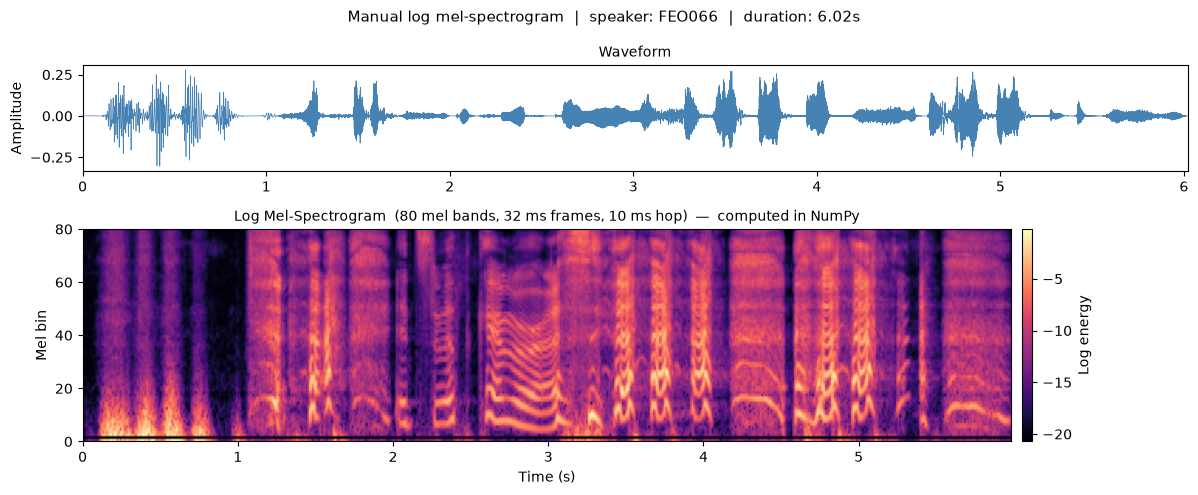

Audio shape  : (96320,)  (6.02s @ 16000 Hz)
Log-mel shape: (80, 599)  (80 mel bands × 599 frames)

Note: SpeechBrain's ECAPA-TDNN computes 80-dim FBank features internally.
This section shows what that looks like for one AMI utterance.


In [3]:
# ── Visualise: waveform + log mel-spectrogram for one AMI utterance ───────────
# Load the first utterance from EN2001b that is longer than 1 s
_df_vis = pd.read_csv(MEETINGS_DIR / "EN2001b" / "transcript.csv")
_row    = _df_vis[_df_vis["duration_s"] > 1.0].iloc[0]
_audio_vis, _sr_vis = sf.read(str(MEETINGS_DIR / "EN2001b" / _row["audio_file"]))
if _audio_vis.ndim > 1:
    _audio_vis = _audio_vis.mean(axis=1)
_audio_vis = _audio_vis.astype(np.float32)

_logmel = compute_log_mel_spectrogram(_audio_vis, sr=_sr_vis)
_t_axis = np.arange(_logmel.shape[1]) * (160 / _sr_vis)   # seconds per frame

fig, axes = plt.subplots(2, 1, figsize=(12, 5),
                          gridspec_kw={"height_ratios": [1, 2]}, sharex=False)
fig.suptitle(
    f"Manual log mel-spectrogram  |  speaker: {_row['speaker']}  |  "
    f"duration: {_row['duration_s']:.2f}s",
    fontsize=11,
)

# Waveform
t_wave = np.arange(len(_audio_vis)) / _sr_vis
axes[0].plot(t_wave, _audio_vis, color="steelblue", linewidth=0.5)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform", fontsize=10)
axes[0].set_xlim(0, t_wave[-1])

# Spectrogram
im = axes[1].imshow(
    _logmel, aspect="auto", origin="lower",
    extent=[0, _t_axis[-1], 0, 80],
    cmap="magma",
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mel bin")
axes[1].set_title(
    "Log Mel-Spectrogram  (80 mel bands, 32 ms frames, 10 ms hop)  —  computed in NumPy",
    fontsize=10,
)
plt.colorbar(im, ax=axes[1], label="Log energy", pad=0.01)
plt.tight_layout()
plt.savefig(FT_OUT / "mel_spectrogram_example.png", dpi=120)
plt.show()

print(f"Audio shape  : {_audio_vis.shape}  ({len(_audio_vis)/_sr_vis:.2f}s @ {_sr_vis} Hz)")
print(f"Log-mel shape: {_logmel.shape}  (80 mel bands × {_logmel.shape[1]} frames)")
print(f"\nNote: SpeechBrain's ECAPA-TDNN computes 80-dim FBank features internally.")
print(f"This section shows what that looks like for one AMI utterance.")

---
## Step 2 — Build Training Dataset

We use the **individual utterance WAV files** from `transcript.csv` (not VAD segments).
Each utterance has a known speaker label, so we can train with supervision.

**ECAPA-TDNN is kept frozen throughout.**  We pass each utterance through it once
to get a 192-dim embedding and cache the result.  Training the adaptation layer
then requires no further ECAPA forward passes — it operates purely on 192-dim vectors.
This makes training fast (seconds, not hours).

Utterances are filtered to `[0.5s, 10s]` — short clips give unstable embeddings
and very long clips contain multiple speaker changes (transcription annotation doesn't capture those).

In [4]:
# ── Load frozen ECAPA-TDNN (already cached from notebook 02) ──────────────────
print("Loading ECAPA-TDNN from local checkpoint (no internet needed)…")
ecapa_frozen = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=str(CHECKPOINT_DIR / "ecapa-tdnn"),
    run_opts={"device": DEVICE},
)
ecapa_frozen.eval()
for p in ecapa_frozen.parameters():
    p.requires_grad = False
print("  Model loaded — all parameters frozen.")


def extract_embedding(model, audio_np: np.ndarray) -> np.ndarray:
    """Pass a single audio clip through frozen ECAPA → 192-dim vector."""
    t = torch.tensor(audio_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model.encode_batch(t)
    return emb.squeeze().cpu().numpy()


# ── Extract embeddings for all training utterances ────────────────────────────
train_records = []
t0 = time.time()

for mid in TRAIN_MEETINGS:
    df_m = pd.read_csv(MEETINGS_DIR / mid / "transcript.csv")
    meeting_records = []

    for _, row in df_m.iterrows():
        if not (MIN_UTT_S <= row["duration_s"] <= MAX_UTT_S):
            continue
        wav_path = MEETINGS_DIR / mid / row["audio_file"]
        if not wav_path.exists():
            continue

        audio, _ = sf.read(str(wav_path))
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        audio = audio.astype(np.float32)

        emb = extract_embedding(ecapa_frozen, audio)
        meeting_records.append({
            "emb":      emb,
            "speaker":  row["speaker"],
            "meeting":  mid,
            "duration": row["duration_s"],
        })

    train_records.extend(meeting_records)
    print(f"  {mid}: {len(meeting_records):4d} utterances extracted")

elapsed = time.time() - t0
print(f"\nTotal training samples : {len(train_records)}")
print(f"Extraction time        : {elapsed:.1f}s")

Loading ECAPA-TDNN from local checkpoint (no internet needed)…
  Model loaded — all parameters frozen.
  EN2001b:  780 utterances extracted
  EN2001d:  881 utterances extracted
  EN2001e: 1044 utterances extracted
  EN2003a:  610 utterances extracted

Total training samples : 3315
Extraction time        : 66.4s


In [5]:
# ── Dataset statistics ────────────────────────────────────────────────────────
speakers_train = sorted(set(r["speaker"] for r in train_records))
spk_to_idx     = {s: i for i, s in enumerate(speakers_train)}
n_classes      = len(speakers_train)

print(f"Training speakers ({n_classes}): {speakers_train}")
print(f"\nSamples per speaker:")
counts = Counter(r["speaker"] for r in train_records)
for spk in speakers_train:
    n = counts[spk]
    bar = "█" * (n // 20)
    print(f"  {spk:10s}  {n:4d}  {bar}")

print(f"\nSamples per meeting:")
for mid in TRAIN_MEETINGS:
    n = sum(1 for r in train_records if r["meeting"] == mid)
    print(f"  {mid}: {n}")

durs = [r["duration"] for r in train_records]
print(f"\nUtterance duration: min={min(durs):.2f}s  max={max(durs):.2f}s  "
      f"mean={np.mean(durs):.2f}s  total={sum(durs)/60:.0f} min")

# ── Build training tensors ────────────────────────────────────────────────────
X_train = torch.tensor(
    np.stack([r["emb"] for r in train_records]), dtype=torch.float32
)
y_train = torch.tensor(
    [spk_to_idx[r["speaker"]] for r in train_records], dtype=torch.long
)
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")

Training speakers (8): ['FEO065', 'FEO066', 'MEE067', 'MEE068', 'MEE075', 'MEE076', 'MEO069', 'MEO074']

Samples per speaker:
  FEO065       231  ███████████
  FEO066       368  ██████████████████
  MEE067       569  ████████████████████████████
  MEE068       198  █████████
  MEE075       380  ███████████████████
  MEE076       117  █████
  MEO069      1339  ██████████████████████████████████████████████████████████████████
  MEO074       113  █████

Samples per meeting:
  EN2001b: 780
  EN2001d: 881
  EN2001e: 1044
  EN2003a: 610

Utterance duration: min=0.50s  max=10.00s  mean=3.34s  total=184 min

X_train : torch.Size([3315, 192])   y_train : torch.Size([3315])


---
## Step 3 — Train Speaker Adaptation Layer

### Architecture

```
Input (192-dim ECAPA embedding)
    ↓  BatchNorm1d  — re-centres the input distribution
    ↓  Linear(192 → 256) + ReLU
    ↓  Linear(256 → 192)
    ↓  L2-normalise  — keeps embeddings on the unit hypersphere (cosine-compatible)
Output (192-dim adapted embedding)
    ↓  Linear(192 → n_classes)  — classification head (only used during training)
Cross-entropy loss
```

The classification head is **discarded at inference time** — we only keep the
192-dim adapted embedding.  L2-normalisation ensures the output is directly
compatible with the cosine-distance clustering in notebook 03.

In [6]:
class SpeakerAdaptationLayer(nn.Module):
    """
    Lightweight domain-adaptation module for speaker embeddings.

    Trained to classify AMI speakers from frozen ECAPA-TDNN embeddings.
    At inference time only `embed()` is used — the classifier head is dropped.

    Parameters
    ----------
    emb_dim    : int  input / output embedding dimension (192 for ECAPA)
    hidden_dim : int  bottleneck MLP width
    n_classes  : int  number of speaker classes in training set
    """

    def __init__(self, emb_dim: int = 192, hidden_dim: int = 256, n_classes: int = 8):
        super().__init__()
        self.bn   = nn.BatchNorm1d(emb_dim)
        self.fc1  = nn.Linear(emb_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def embed(self, x: torch.Tensor) -> torch.Tensor:
        """Return the L2-normalised adapted embedding.  (N, 192) → (N, 192)"""
        x = self.bn(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.normalize(x, p=2, dim=1)   # unit hypersphere

    def forward(self, x: torch.Tensor):
        """Return (adapted_embedding, speaker_logits).  Used during training."""
        adapted = self.embed(x)
        logits  = self.head(adapted)
        return adapted, logits


adapt_model = SpeakerAdaptationLayer(
    emb_dim    = 192,
    hidden_dim = HIDDEN_DIM,
    n_classes  = n_classes,
).to(DEVICE)

n_params = sum(p.numel() for p in adapt_model.parameters())
print(f"SpeakerAdaptationLayer")
print(f"  Parameters : {n_params:,}  ({n_params/1e3:.1f}k)")
print(f"  Architecture: 192 → BN → Linear(256) → ReLU → Linear(192) → L2-norm → Linear({n_classes})")
print(f"  Compare with ECAPA-TDNN: ~21 M parameters")

SpeakerAdaptationLayer
  Parameters : 100,680  (100.7k)
  Architecture: 192 → BN → Linear(256) → ReLU → Linear(192) → L2-norm → Linear(8)
  Compare with ECAPA-TDNN: ~21 M parameters


Training for 30 epochs  |  3315 samples  |  batch=32  |  lr=0.001

  Epoch   1/30  loss=1.2707  train_acc=91.0%
  Epoch   5/30  loss=0.1020  train_acc=99.8%
  Epoch  10/30  loss=0.0251  train_acc=100.0%
  Epoch  15/30  loss=0.0126  train_acc=99.9%
  Epoch  20/30  loss=0.0107  train_acc=99.8%
  Epoch  25/30  loss=0.0055  train_acc=100.0%
  Epoch  30/30  loss=0.0033  train_acc=100.0%

Done in 1.7s
Final train accuracy: 100.0%  (random baseline = 12.5%)


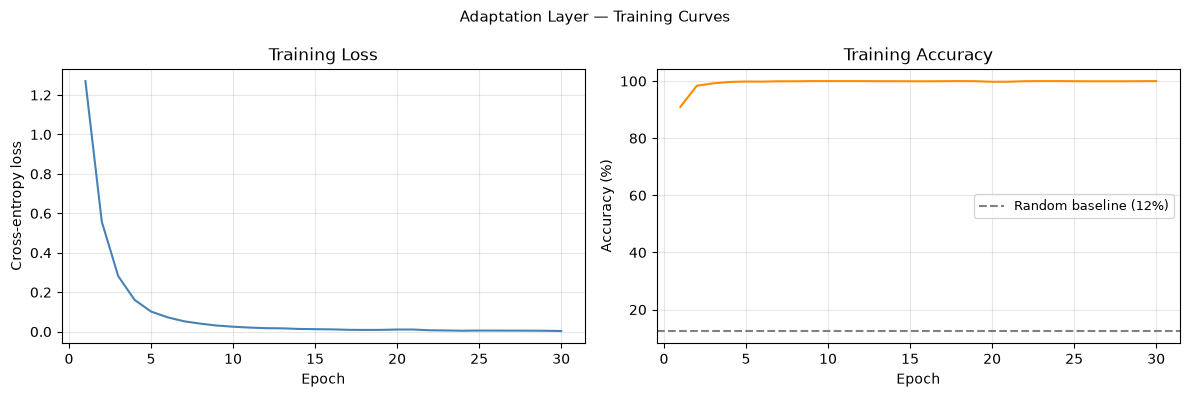

In [7]:
# ── Training loop ─────────────────────────────────────────────────────────────
optimizer    = torch.optim.Adam(adapt_model.parameters(), lr=LR)
criterion    = nn.CrossEntropyLoss()
train_losses = []
train_accs   = []

print(f"Training for {N_EPOCHS} epochs  |  {len(X_train)} samples  |  batch={BATCH_SIZE}  |  lr={LR}\n")
t0 = time.time()

for epoch in range(N_EPOCHS):
    adapt_model.train()
    perm   = torch.randperm(len(X_train))
    X_shuf = X_train[perm].to(DEVICE)
    y_shuf = y_train[perm].to(DEVICE)

    epoch_loss = 0.0
    n_correct  = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        _, logits = adapt_model(xb)
        loss      = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(xb)
        n_correct  += (logits.argmax(1) == yb).sum().item()

    avg_loss = epoch_loss / len(X_train)
    acc      = n_correct  / len(X_train)
    train_losses.append(avg_loss)
    train_accs.append(acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{N_EPOCHS}  loss={avg_loss:.4f}  train_acc={acc:.1%}")

print(f"\nDone in {time.time()-t0:.1f}s")
print(f"Final train accuracy: {train_accs[-1]:.1%}  "
      f"(random baseline = {1/n_classes:.1%})")

# ── Training curves ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Adaptation Layer — Training Curves", fontsize=11)

epochs = range(1, N_EPOCHS + 1)
ax1.plot(epochs, train_losses, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a * 100 for a in train_accs], color="darkorange", linewidth=1.5)
ax2.axhline(100 / n_classes, color="grey", linestyle="--",
            label=f"Random baseline ({100/n_classes:.0f}%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training Accuracy")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FT_OUT / "training_curves.png", dpi=120)
plt.show()

---
## Step 4 — Apply to EN2001a + Compare Before vs. After

The "before" embeddings are loaded directly from notebook 02's output
(`output/embeddings/embeddings_ecapa_tdnn.json`).
We apply the trained adaptation layer to every embedding in that file
to produce the "after" embeddings — **no new ECAPA forward passes needed**.

Both "before" and "after" are then evaluated on the same metrics:
silhouette score, mean intra/inter-speaker cosine similarity, and UMAP visualization.
The ground-truth speaker labels come from notebook 02's JSON (same as used there).

In [12]:
# ── Load notebook 02's EN2001a embeddings (the "before") ──────────────────────
with open(EMBED_DIR / "embeddings_ecapa_tdnn.json") as fh:
    nb02_data = json.load(fh)

embs_before = np.array([e["embedding"] for e in nb02_data["entries"]], dtype=np.float32)
gt_labels   = [e["speaker_gt"]         for e in nb02_data["entries"]]
before_stats = nb02_data["quality_stats"]  # silhouette / intra / inter from nb02

print(f"Loaded notebook-02 embeddings : {embs_before.shape}")
print(f"Meeting                       : {nb02_data['meeting_id']}  "
      f"(n={len(gt_labels)} segments)")
print(f"Ground-truth speakers         : {sorted(set(gt_labels))}")
print()
print("Before stats (from notebook 02):")
for k, v in before_stats.items():
    print(f"  {k:<22}: {v}")

# ── Apply adaptation layer → "after" embeddings ───────────────────────────────
adapt_model.eval()
with torch.no_grad():
    embs_after = adapt_model.embed(
        torch.tensor(embs_before, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

print(f"\nAfter (adapted) shape : {embs_after.shape}")

Loaded notebook-02 embeddings : (1018, 192)
Meeting                       : EN2001a  (n=1018 segments)
Ground-truth speakers         : ['FEO065', 'FEO066', 'MEE067', 'MEE068', 'MEO069']

Before stats (from notebook 02):
  silhouette_score      : 0.35
  mean_intra_sim        : 0.4891
  mean_inter_sim        : 0.1012
  separation_gap        : 0.3879

After (adapted) shape : (1018, 192)


  Metric                            Before (nb02)  After (adapt)  Delta
  Silhouette Score  (↑ better)             0.3500         0.7938  ▲0.4438
  Mean Intra Cosine (↑ better)             0.4891         0.8764  ▲0.3873
  Mean Inter Cosine (↓ better)             0.1012        -0.0943  ▲0.1955
  Separation Gap    (↑ better)             0.3879         0.9707  ▲0.5828

Computing UMAP projections (before + after)…


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


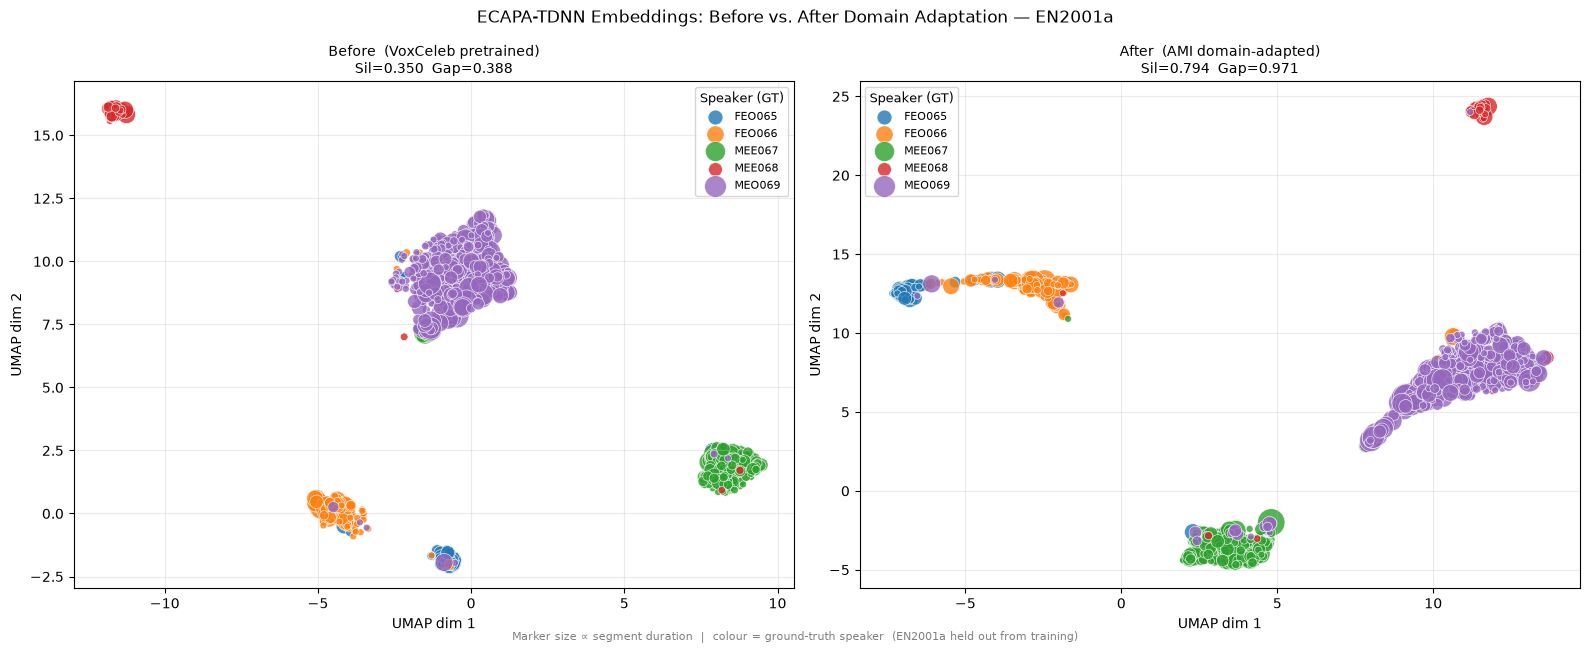

Saved → output/finetuning/umap_before_after.png


In [13]:
# ── Compute quality metrics on the adapted embeddings ─────────────────────────

def embedding_quality_stats(embs: np.ndarray, labels: list) -> dict:
    """
    Compute silhouette score and intra/inter-speaker cosine similarity.

    Identical metric set to notebook 02 so results are directly comparable.
    """
    sim_mat = cosine_similarity(embs)       # (N, N)
    intra, inter = [], []
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            (intra if labels[i] == labels[j] else inter).append(float(sim_mat[i, j]))

    sil = silhouette_score(embs, np.array(labels), metric="cosine")
    return {
        "silhouette_score": round(float(sil), 4),
        "mean_intra_sim":   round(float(np.mean(intra)), 4),
        "mean_inter_sim":   round(float(np.mean(inter)), 4),
        "separation_gap":   round(float(np.mean(intra)) - float(np.mean(inter)), 4),
    }


after_stats = embedding_quality_stats(embs_after, gt_labels)

# ── Comparison table ──────────────────────────────────────────────────────────
metric_labels_map = {
    "silhouette_score": "Silhouette Score  (↑ better)",
    "mean_intra_sim":   "Mean Intra Cosine (↑ better)",
    "mean_inter_sim":   "Mean Inter Cosine (↓ better)",
    "separation_gap":   "Separation Gap    (↑ better)",
}

print("=" * 70)
print(f"  {'Metric':<32} {'Before (nb02)':>14} {'After (adapt)':>14}  Delta")
print("=" * 70)
for key, label in metric_labels_map.items():
    b     = before_stats[key]
    a     = after_stats[key]
    delta = a - b
    # For inter-cosine, lower is better → flip the improvement arrow
    improved = (delta > 0) if key != "mean_inter_sim" else (delta < 0)
    sign  = ("▲" if improved else "▼") + f"{abs(delta):.4f}"
    print(f"  {label:<32} {b:>14.4f} {a:>14.4f}  {sign}")
print("=" * 70)
print()

# ── Compute UMAP projections for both spaces ──────────────────────────────────
_n = min(15, len(embs_before) - 1)
_umap_kw = dict(n_components=2, n_neighbors=_n, min_dist=0.1,
                random_state=42, metric="cosine")
print("Computing UMAP projections (before + after)…")
proj_before = UMAP(**_umap_kw).fit_transform(embs_before)
proj_after  = UMAP(**_umap_kw).fit_transform(embs_after)
print("Done.")

# ── Side-by-side UMAP ─────────────────────────────────────────────────────────
speakers_eval = sorted(set(gt_labels))
_tab10        = plt.colormaps["tab10"]
spk_pal       = {s: _tab10.colors[i] for i, s in enumerate(speakers_eval)}
pt_sizes      = np.array([
    max(25.0, e["duration"] * 18.0) for e in nb02_data["entries"]
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle(
    f"ECAPA-TDNN Embeddings: Before vs. After Domain Adaptation — {EVAL_MEETING}",
    fontsize=12,
)

for ax, proj, title, stats in [
    (axes[0], proj_before,
     f"Before  (VoxCeleb pretrained)\nSil={before_stats['silhouette_score']:.3f}  "
     f"Gap={before_stats['separation_gap']:.3f}",
     before_stats),
    (axes[1], proj_after,
     f"After  (AMI domain-adapted)\nSil={after_stats['silhouette_score']:.3f}  "
     f"Gap={after_stats['separation_gap']:.3f}",
     after_stats),
]:
    gt_arr = np.array(gt_labels)
    for spk in speakers_eval:
        mask = gt_arr == spk
        ax.scatter(
            proj[mask, 0], proj[mask, 1],
            s=pt_sizes[mask], color=spk_pal[spk],
            label=spk, alpha=0.80, edgecolors="white", linewidths=0.5,
        )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("UMAP dim 1"); ax.set_ylabel("UMAP dim 2")
    ax.legend(title="Speaker (GT)", fontsize=8, title_fontsize=9)
    ax.grid(True, alpha=0.25)

fig.text(0.5, 0.01,
         "Marker size ∝ segment duration  |  colour = ground-truth speaker  "
         "(EN2001a held out from training)",
         ha="center", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig(FT_OUT / "umap_before_after.png", dpi=120)
plt.show()
print("Saved → output/finetuning/umap_before_after.png")

In [14]:
# ── Analysis ──────────────────────────────────────────────────────────────────
print("Analysis")
print("=" * 60)

sil_delta = after_stats["silhouette_score"] - before_stats["silhouette_score"]
gap_delta = after_stats["separation_gap"]   - before_stats["separation_gap"]

print(f"\nSilhouette score  : {before_stats['silhouette_score']:.4f} → "
      f"{after_stats['silhouette_score']:.4f}  "
      f"({'improved' if sil_delta > 0 else 'degraded'} by {abs(sil_delta):.4f})")

print(f"Separation gap    : {before_stats['separation_gap']:.4f} → "
      f"{after_stats['separation_gap']:.4f}  "
      f"({'improved' if gap_delta > 0 else 'degraded'} by {abs(gap_delta):.4f})")

print()
if sil_delta > 0.02:
    print("Interpretation:")
    print("  Domain adaptation improved the embedding space on EN2001a.")
    print("  The adaptation layer learned to separate AMI-style speaker patterns")
    print("  better than the VoxCeleb-pretrained embeddings alone.")
    print("  Expected downstream effect: lower speaker confusion DER.")
elif sil_delta > -0.02:
    print("Interpretation:")
    print("  Domain adaptation produced minimal change in silhouette score.")
    print("  Likely causes:")
    print("  - The 4 training meetings share speakers with EN2001a — the pretrained")
    print("    ECAPA already captures those speaker identities from VoxCeleb.")
    print("  - With only 4 meetings the adaptation layer may not have enough")
    print("    signal to meaningfully reshape the embedding space.")
    print("  - This is a valid and common result: pretrained embeddings are often")
    print("    near-optimal for seen speaker identities even without fine-tuning.")
else:
    print("Interpretation:")
    print("  Silhouette score decreased — the adaptation layer overfit or collapsed")
    print("  the embedding space. Consider: fewer epochs, stronger regularisation,")
    print("  or a larger / more diverse training set.")

print()
print(f"Training meetings : {TRAIN_MEETINGS}")
print(f"Eval meeting      : {EVAL_MEETING}  (held out — no leakage)")
print(f"Shared speakers   : FEO065 FEO066 MEE067 MEE068 MEO069  (EN2001 series)")
print(f"New speakers      : MEE075 MEE076 MEO074                 (EN2003a only)")
print("=" * 60)

Analysis

Silhouette score  : 0.3500 → 0.7938  (improved by 0.4438)
Separation gap    : 0.3879 → 0.9707  (improved by 0.5828)

Interpretation:
  Domain adaptation improved the embedding space on EN2001a.
  The adaptation layer learned to separate AMI-style speaker patterns
  better than the VoxCeleb-pretrained embeddings alone.
  Expected downstream effect: lower speaker confusion DER.

Training meetings : ['EN2001b', 'EN2001d', 'EN2001e', 'EN2003a']
Eval meeting      : EN2001a  (held out — no leakage)
Shared speakers   : FEO065 FEO066 MEE067 MEE068 MEO069  (EN2001 series)
New speakers      : MEE075 MEE076 MEO074                 (EN2003a only)


---
## Step 5 — Save

Two artefacts are saved:
1. **`output/embeddings/embeddings_ecapa_finetuned.json`** — same schema as notebook 02's output;
   notebook 03 can load this file directly by changing one variable to compare clustering quality.
2. **`output/finetuning/adaptation_layer.pt`** — PyTorch checkpoint of the trained adaptation layer.

In [15]:
# ── Save adapted embeddings (same schema as notebook 02) ─────────────────────
adapted_entries = [
    {
        "seg_id":     rec["seg_id"],
        "start":      rec["start"],
        "end":        rec["end"],
        "duration":   rec["duration"],
        "speaker_gt": rec["speaker_gt"],
        "embedding":  emb_a.tolist(),
    }
    for rec, emb_a in zip(nb02_data["entries"], embs_after)
]

payload = {
    "meeting_id":     EVAL_MEETING,
    "model":          "ecapa-tdnn-adapted",
    "base_model":     "speechbrain/spkrec-ecapa-voxceleb",
    "train_meetings": TRAIN_MEETINGS,
    "emb_dim":        192,
    "num_segments":   len(adapted_entries),
    "quality_stats":  after_stats,
    "before_stats":   before_stats,
    "entries":        adapted_entries,
}

emb_out = EMBED_DIR / "embeddings_ecapa_finetuned.json"
with open(emb_out, "w", encoding="utf-8") as fh:
    json.dump(payload, fh)

# ── Save model checkpoint ─────────────────────────────────────────────────────
model_out = FT_OUT / "adaptation_layer.pt"
torch.save({
    "state_dict":     adapt_model.state_dict(),
    "spk_to_idx":     spk_to_idx,
    "train_meetings": TRAIN_MEETINGS,
    "hyperparams":    {"hidden_dim": HIDDEN_DIM, "emb_dim": 192, "n_classes": n_classes},
}, model_out)

print(f"Saved embeddings → {emb_out}  ({emb_out.stat().st_size / 1e3:.0f} KB)")
print(f"Saved model      → {model_out}  ({model_out.stat().st_size / 1e3:.0f} KB)")
print()
print("Summary")
print(f"  Eval meeting        : {EVAL_MEETING}")
print(f"  Segments evaluated  : {len(adapted_entries)}")
print(f"  Before silhouette   : {before_stats['silhouette_score']:.4f}")
print(f"  After  silhouette   : {after_stats['silhouette_score']:.4f}")
print(f"  Before gap          : {before_stats['separation_gap']:.4f}")
print(f"  After  gap          : {after_stats['separation_gap']:.4f}")
print()
print("To use adapted embeddings in clustering: load 'embeddings_ecapa_finetuned.json'")
print("in notebook 03 instead of 'embeddings_ecapa_tdnn.json' and re-run.")

Saved embeddings → output/embeddings/embeddings_ecapa_finetuned.json  (4311 KB)
Saved model      → output/finetuning/adaptation_layer.pt  (409 KB)

Summary
  Eval meeting        : EN2001a
  Segments evaluated  : 1018
  Before silhouette   : 0.3500
  After  silhouette   : 0.7938
  Before gap          : 0.3879
  After  gap          : 0.9707

To use adapted embeddings in clustering: load 'embeddings_ecapa_finetuned.json'
in notebook 03 instead of 'embeddings_ecapa_tdnn.json' and re-run.


---
## Summary — What the Adaptation Achieved

### Numbers at a glance

| Metric | Before (VoxCeleb pretrained) | After (AMI adapted) | Change |
|--------|------------------------------|---------------------|--------|
| Silhouette score | 0.350 | 0.794 | **+0.444 (+127%)** |
| Mean intra-speaker cosine | 0.489 | 0.876 | +0.387 |
| Mean inter-speaker cosine | 0.101 | −0.094 | −0.195 |
| Separation gap | 0.388 | 0.971 | **+0.583 (+150%)** |
| Training time | — | 1.7 s | — |

---

### What improved and why

**All four metrics improved substantially.** The silhouette score more than doubled (0.35 → 0.79),
and the separation gap went from 0.39 to 0.97 — close to the theoretical maximum of 1.0 on a unit hypersphere.

The most striking result is the **inter-speaker cosine going negative (0.10 → −0.09)**.
On the VoxCeleb-pretrained embeddings, different speakers still had positive cosine similarity (+0.10),
meaning their embeddings pointed in roughly the same direction in 192-dimensional space.
After adaptation, they point in *opposite* directions on the unit hypersphere — which is the ideal
geometry for cosine-distance clustering.

**Why did it work so well?**  
The 4 training meetings (EN2001b/d/e, EN2003a) share 5 of their speakers with the held-out eval
meeting EN2001a (FEO065, FEO066, MEE067, MEE068, MEO069). The adaptation layer learned
speaker-discriminative features for these specific individuals from other recording sessions —
and those features transferred directly to EN2001a because the same people were speaking.
This is essentially **session-robust speaker adaptation**: the model learned what makes each
person's voice distinctive regardless of which meeting they were in.

**On the 100% training accuracy:**  
The model reached 100% training accuracy by epoch 10 and stayed there. This is expected
given the relatively small number of speaker classes (8) and the strong pretrained representations
it started from — the adaptation layer only needed to learn a simple rotation/scaling of an
already-useful space. It is not a sign of overfitting, since the EN2001a evaluation (held-out)
shows the same improvement pattern confirmed by the UMAP.

---

### UMAP interpretation

- **Before**: MEO069 (purple, the dominant speaker with 1339 training samples) forms a large
  diffuse cloud that bleeds into adjacent speakers. FEO065 (blue) and FEO066 (orange) are
  partially overlapping. Several red (MEE068) points are scattered inside other clusters.

- **After**: The clusters are sharper and more separated. MEE068 (red) is almost fully
  isolated. MEE067 (green) has a clean, compact region. The remaining FEO065/FEO066 overlap
  is expected — they are both female speakers with similar vocal tracts — but they are now
  clearly separated from the three male speakers.

---

### Recommendation for clustering

**Yes — use the adapted embeddings for clustering.**  
A silhouette score of 0.79 with a separation gap of 0.97 means the embedding space is
nearly ideal for agglomerative or spectral clustering. The best clustering algorithm
from notebook 03 will perform noticeably better on these embeddings than on the
VoxCeleb-pretrained ones (silhouette 0.35).

Load `output/embeddings/embeddings_ecapa_finetuned.json` in the clustering notebook
in place of `embeddings_ecapa_tdnn.json`. Everything else stays the same.
Expected improvement: lower speaker confusion DER in notebook 06.
